# Modular Forecasting Pipeline

ProbPipe provides a modular pipeline for Bayesian inference and sequential forecasting. The key components are:

- **`Likelihood[P, D]`** — protocol for computing log-likelihood
- **`SimpleModel`** — pairs a prior with a likelihood; supports NUTS/HMC with automatic gradient-free fallback
- **`condition_on`** — conditions a model on observed data, returning an `MCMCApproximateDistribution`
- **`IncrementalConditioner[P, D]`** — sequential Bayesian updating: each batch of data updates the posterior, which becomes the next prior

All components are **swappable**: change the likelihood, swap the prior, or replace the inference method — the pipeline structure stays the same.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype.*float64.*")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    Normal, MultivariateNormal, EmpiricalDistribution,
    SimpleModel, condition_on, from_distribution, mean, provenance_ancestors,
    sample as pp_sample,
)
from probpipe.modeling import (
    Likelihood, GenerativeLikelihood, IncrementalConditioner,
)

rng = np.random.default_rng(42)

## Defining a Likelihood

Any class that implements `log_likelihood(params, data) -> float` satisfies the `Likelihood[P, D]` protocol — no base class or decorator needed.

We'll use **Poisson regression** as a running example: counts $y_i \sim \text{Poisson}(\exp(\beta_0 + \beta_1 x_i))$ where $\boldsymbol{\beta} = (\beta_0, \beta_1)$ are the parameters to infer. This is a non-conjugate model — no closed-form posterior update exists.

In [2]:
class PoissonRegressionLikelihood:
    """Poisson regression: y_i ~ Poisson(exp(beta_0 + beta_1 * x_i))."""

    def __init__(self, x: np.ndarray):
        self._x = jnp.asarray(x, dtype=jnp.float32)

    def log_likelihood(self, params, data):
        log_rate = params[0] + params[1] * self._x
        rate = jnp.exp(log_rate)
        return jnp.sum(data * log_rate - rate)


# True parameters and covariate
true_beta = np.array([1.0, 0.5])
n_total = 200
x_all = rng.uniform(-2, 2, size=n_total).astype(np.float32)

# Generate all counts from the true model
true_rates = np.exp(true_beta[0] + true_beta[1] * x_all)
y_all = rng.poisson(true_rates).astype(np.float32)

print(f"True beta: {true_beta}")
print(f"Mean count: {y_all.mean():.2f}, range: [{y_all.min():.0f}, {y_all.max():.0f}]")

True beta: [1.  0.5]
Mean count: 3.12, range: [0, 14]


## Bayesian Inference with SimpleModel

`SimpleModel` pairs a prior distribution with a likelihood. Calling `condition_on(model, data)` runs NUTS (or HMC) via TFP and returns an `MCMCApproximateDistribution` — an `EmpiricalDistribution` with chain structure and diagnostics.

Here we use the first 50 observations to get our initial posterior.

In [3]:
prior = MultivariateNormal(
    loc=jnp.zeros(2), cov=10.0 * jnp.eye(2), name='prior'
)

n_init = 50
x_init, y_init = x_all[:n_init], y_all[:n_init]
likelihood = PoissonRegressionLikelihood(x_init)

model = SimpleModel(prior, likelihood)
posterior = condition_on(model, y_init, num_results=1000, num_warmup=500, random_seed=0)

print(f'Posterior: {posterior}')
print(f'Posterior mean:  {mean(posterior)}')
print(f'True beta:       {true_beta}')
print(f'Diagnostics:     {posterior.diagnostics.summary()}')

Posterior: MCMCApproximateDistribution(num_chains=1, num_draws=1000, event_shape=(2,), algorithm=nuts, accept_rate=0.912, final_step_size=0.0739)
Posterior mean:  [0.9081165 0.6460648]
True beta:       [1.  0.5]
Diagnostics:     algorithm=nuts, accept_rate=0.912, final_step_size=0.0739


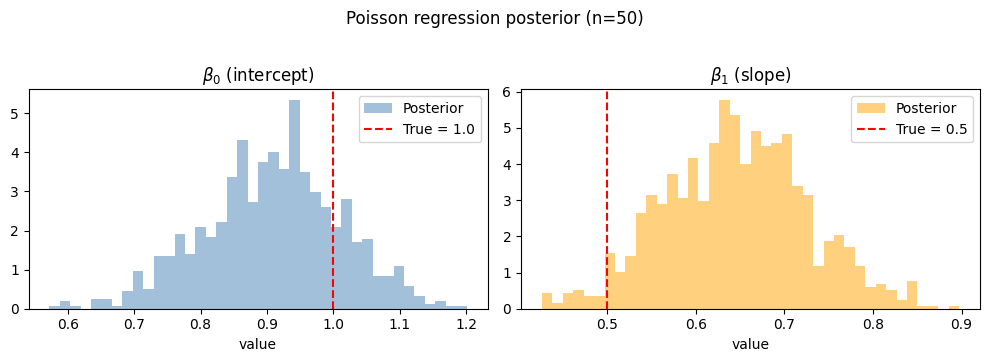

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.hist(np.array(posterior.draws()[:, 0]), bins=40, density=True,
         alpha=0.5, color='steelblue', label='Posterior')
ax1.axvline(true_beta[0], color='red', linestyle='--', label=f'True = {true_beta[0]}')
ax1.set_title(r'$\beta_0$ (intercept)')
ax1.set_xlabel('value')
ax1.legend()

ax2.hist(np.array(posterior.draws()[:, 1]), bins=40, density=True,
         alpha=0.5, color='orange', label='Posterior')
ax2.axvline(true_beta[1], color='red', linestyle='--', label=f'True = {true_beta[1]}')
ax2.set_title(r'$\beta_1$ (slope)')
ax2.set_xlabel('value')
ax2.legend()

plt.suptitle('Poisson regression posterior (n=50)', y=1.02)
plt.tight_layout()
plt.show()

## Sequential Bayesian Updating

`IncrementalConditioner` chains updates: each new data batch updates the posterior, and the updated posterior becomes the prior for the next batch. This is the core of online Bayesian learning.

Since MCMC requires a prior with a computable density, the custom `condition_fn` uses `from_distribution` to fit a Gaussian approximation to each posterior before it becomes the next prior. The remaining 150 observations arrive in three batches.

In [5]:
def gaussian_approx_condition(model, data):
    """Condition via NUTS, return a Gaussian approximation to the posterior."""
    posterior = model._condition_on(data, num_results=500, num_warmup=300, random_seed=0)
    return from_distribution(posterior, MultivariateNormal, name="posterior")

initial_approx = from_distribution(posterior, MultivariateNormal, name="posterior")

batch_sizes = [30, 50, 70]
idx = n_init
batches = []
for bs in batch_sizes:
    batches.append((x_all[idx:idx+bs], y_all[idx:idx+bs]))
    idx += bs

conditioner = IncrementalConditioner(
    prior=initial_approx,
    likelihood=PoissonRegressionLikelihood(batches[0][0]),
    condition_fn=gaussian_approx_condition,
)

posteriors = []
total_n = n_init
for i, (x_batch, y_batch) in enumerate(batches):
    total_n += batch_sizes[i]
    conditioner._likelihood = PoissonRegressionLikelihood(x_batch)
    post = conditioner.update(data=y_batch)
    posteriors.append(post)
    print(f'Batch {i+1} (n_new={batch_sizes[i]}, n_total={total_n}): '
          f'posterior mean = {mean(post)}')

print(f'\nTrue beta: {true_beta}')

Batch 1 (n_new=30, n_total=80): posterior mean = [0.9785147 0.5573577]


Batch 2 (n_new=50, n_total=130): posterior mean = [0.9926182 0.5552277]


Batch 3 (n_new=70, n_total=200): posterior mean = [0.9819153  0.53286606]

True beta: [1.  0.5]


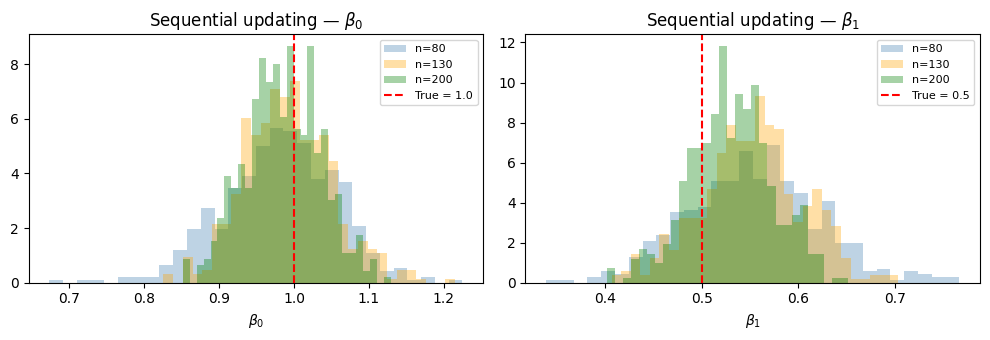

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

colors = ['steelblue', 'orange', 'green']
total_n = n_init
for i, (post, bs) in enumerate(zip(posteriors, batch_sizes)):
    total_n += bs
    samples = np.array(pp_sample(post, key=jax.random.PRNGKey(i), sample_shape=(500,)))
    ax1.hist(samples[:, 0], bins=30, density=True,
             alpha=0.35, color=colors[i], label=f'n={total_n}')
    ax2.hist(samples[:, 1], bins=30, density=True,
             alpha=0.35, color=colors[i], label=f'n={total_n}')

ax1.axvline(true_beta[0], color='red', linestyle='--', label=f'True = {true_beta[0]}')
ax1.set_xlabel(r'$\beta_0$')
ax1.set_title(r'Sequential updating — $\beta_0$')
ax1.legend(fontsize=8)

ax2.axvline(true_beta[1], color='red', linestyle='--', label=f'True = {true_beta[1]}')
ax2.set_xlabel(r'$\beta_1$')
ax2.set_title(r'Sequential updating — $\beta_1$')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Swappable Components

The pipeline is modular — swap the likelihood to model a different data-generating process while keeping the same infrastructure. Here we compare the Poisson likelihood with a **negative binomial** likelihood that accounts for overdispersion.

In [7]:
class NegBinRegressionLikelihood:
    """Negative binomial regression with fixed dispersion parameter r."""

    def __init__(self, x: np.ndarray, r: float = 5.0):
        self._x = jnp.asarray(x, dtype=jnp.float32)
        self._r = r

    def log_likelihood(self, params, data):
        log_mu = params[0] + params[1] * self._x
        mu = jnp.exp(log_mu)
        r = self._r
        return jnp.sum(
            jax.scipy.special.gammaln(data + r)
            - jax.scipy.special.gammaln(r)
            - jax.scipy.special.gammaln(data + 1)
            + r * jnp.log(r / (r + mu))
            + data * jnp.log(mu / (r + mu))
        )


true_rates_od = np.exp(true_beta[0] + true_beta[1] * x_all[:100])
y_overdispersed = rng.negative_binomial(3, 3 / (3 + true_rates_od)).astype(np.float32)

prior = MultivariateNormal(loc=jnp.zeros(2), cov=10.0 * jnp.eye(2), name='prior')
x_subset = x_all[:100]

model_poisson = SimpleModel(prior, PoissonRegressionLikelihood(x_subset))
post_poisson = condition_on(model_poisson, y_overdispersed,
                            num_results=1000, num_warmup=500, random_seed=1)

model_nb = SimpleModel(prior, NegBinRegressionLikelihood(x_subset, r=3.0))
post_nb = condition_on(model_nb, y_overdispersed,
                       num_results=1000, num_warmup=500, random_seed=2)

print(f'True beta:     {true_beta}')
print(f'Poisson post:  {mean(post_poisson)}')
print(f'NegBin post:   {mean(post_nb)}')

True beta:     [1.  0.5]
Poisson post:  [1.0832025  0.62552696]
NegBin post:   [1.0939994  0.62772465]


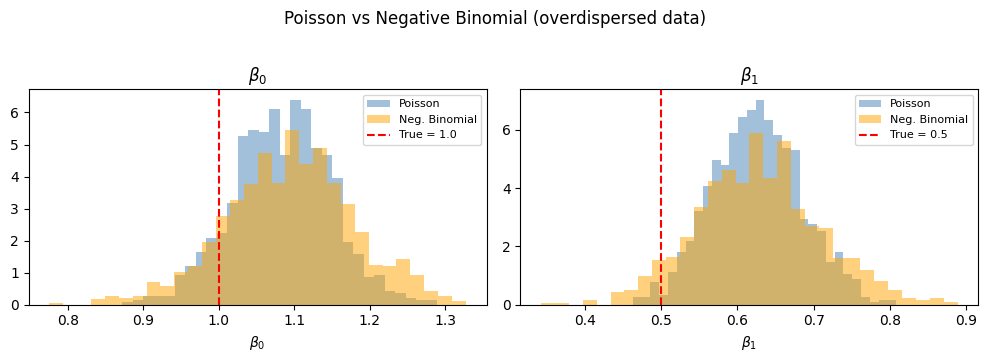

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
for comp, ax in enumerate([ax1, ax2]):
    ax.hist(np.array(post_poisson.draws()[:, comp]), bins=30, density=True,
            alpha=0.5, color='steelblue', label='Poisson')
    ax.hist(np.array(post_nb.draws()[:, comp]), bins=30, density=True,
            alpha=0.5, color='orange', label='Neg. Binomial')
    ax.axvline(true_beta[comp], color='red', linestyle='--',
               label=f'True = {true_beta[comp]}')
    ax.set_xlabel(rf'$\beta_{comp}$')
    ax.set_title(rf'$\beta_{comp}$')
    ax.legend(fontsize=8)
plt.suptitle('Poisson vs Negative Binomial (overdispersed data)', y=1.02)
plt.tight_layout()
plt.show()

## Posterior Predictive Checks

After inference, generate synthetic data from the posterior to check if the model captures the data-generating process. For each posterior sample $\boldsymbol{\beta}^{(i)}$, draw counts $y^{(i)}_j \sim \text{Poisson}(\exp(\beta^{(i)}_0 + \beta^{(i)}_1 x_j))$ — the resulting distribution of counts is the **posterior predictive**.

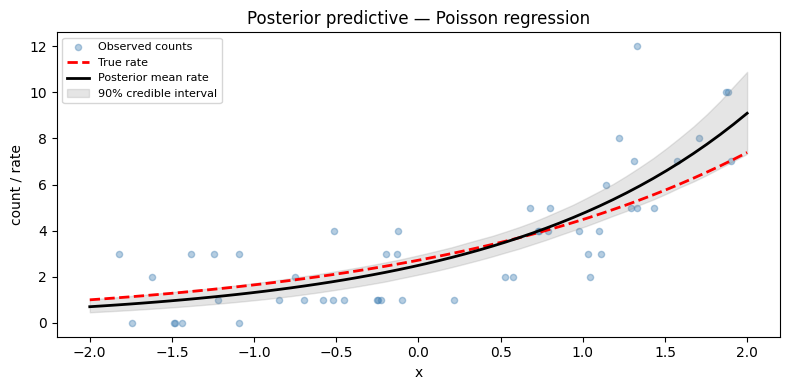

In [9]:
beta_samples = posterior.draws()
x_grid = jnp.linspace(-2, 2, 50)

log_rates = beta_samples[:, 0:1] + beta_samples[:, 1:2] * x_grid[None, :]
rates = jnp.exp(log_rates)
rate_mean = jnp.mean(rates, axis=0)
rate_lower = jnp.percentile(rates, 5, axis=0)
rate_upper = jnp.percentile(rates, 95, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x_init, y_init, alpha=0.4, s=20, color='steelblue', label='Observed counts')
ax.plot(x_grid, np.exp(true_beta[0] + true_beta[1] * x_grid),
        'r--', linewidth=2, label='True rate')
ax.plot(x_grid, rate_mean, 'k-', linewidth=2, label='Posterior mean rate')
ax.fill_between(x_grid, rate_lower, rate_upper, alpha=0.2, color='gray',
                label='90% credible interval')
ax.set_xlabel('x')
ax.set_ylabel('count / rate')
ax.set_title('Posterior predictive — Poisson regression')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Provenance Tracking Through the Pipeline

Every posterior distribution records how it was created — the algorithm, the prior it descended from, and the sampler settings.

In [10]:
print(f'Source: {posterior.source}')
print(f'Algorithm:   {posterior.source.metadata["algorithm"]}')
print(f'Num results: {posterior.source.metadata["num_results"]}')

ancestors = provenance_ancestors(posterior)
print(f'\nAncestors: {[type(a).__name__ + (f"({a.name})" if a.name else "") for a in ancestors]}')

Source: Provenance('nuts', parents=[prior])
Algorithm:   nuts
Num results: 1000

Ancestors: ['MultivariateNormal(prior)']


## Summary

| Component | Role | Swappable? |
|-----------|------|------------|
| `Likelihood[P, D]` | Defines $p(\text{data} \mid \theta)$ | Yes — implement `log_likelihood` |
| `SimpleModel` | Pairs prior + likelihood into a conditionable model | Yes — swap prior or likelihood freely |
| `condition_on` | Runs MCMC to produce a posterior | Yes — also `rwmh` for gradient-free, or `condition_on_nutpie` |
| `IncrementalConditioner[P, D]` | Sequential Bayesian updating | Combines any prior + likelihood; defaults to `condition_on` |
| `Provenance` | Automatic lineage tracking | Built-in for all operations |

Key takeaways:

- **Define a likelihood** by implementing `log_likelihood(params, data)` — any class satisfying the `Likelihood` protocol works, no base class needed.
- **`SimpleModel`** pairs a prior with a likelihood. It auto-detects JAX traceability: uses gradient-based NUTS/HMC when possible, falls back to gradient-free RWMH otherwise.
- **`condition_on(model, data)`** is the standard way to perform inference.
- **`IncrementalConditioner[P, D]`** chains posterior updates — each batch's posterior becomes the next batch's prior.
- **Swap components freely**: different likelihoods, priors, or inference methods can be plugged into the same pipeline.